# Tanager Mangrove Mapping - 02b Multispectral-Equivalent Classification

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent and Biomass Mapping Using Adaptive Spectral Thresholds |
| **Date**        | July 2026 |

---

**Scope (Scenario B - journal publication only):** Train XGBoost classifier on Scenario B pseudo-labels (4-feature stack from `01b`), predict mangrove extent for Sangatta, evaluate against GMW v3 to obtain Kappa B. Compare against XGBoost Tuned Scenario A (6-feature stack) at the training site.

**Model configuration:** XGBoost Tuned only. Hyperparameters loaded from Scenario A saved JSON (`xgb_best_params_sangatta_....json`) and applied unchanged. Rationale: isolate the effect of feature stack (drop REIP, EMI) from any confounding effect of hyperparameter re-tuning or model choice. Both scenarios use the same model family (XGBoost) with the same hyperparameters. Only the feature stack differs.

**Note on `scale_pos_weight`:** recomputed from Scenario B class ratio because it depends on the training data itself, not on hyperparameter choices.

## 0. Environment Setup

In [14]:
# !pip install scikit-learn geopandas rasterio matplotlib joblib xgboost


In [15]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root and paths
# ============================================================
# Google Colab (Google Drive mounted)
ROOT           = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
# ROOT = Path('..').resolve()
DATA_PROC      = ROOT / 'data' / 'processed'
DATA_PROC_S2EQ = ROOT / 'data' / 'processed_s2eq'
DATA_GMW       = ROOT / 'data' / 'gmw_v3'
OUT_MODELS     = ROOT / 'outputs' / 'models'
OUT_RESULTS    = ROOT / 'outputs' / 'results'
OUT_FIGURES    = ROOT / 'outputs' / 'figures'

for d in (OUT_MODELS, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

# ============================================================
# Reload src modules during development
# ============================================================
import src.classification as _cls
import src.evaluation     as _eval
importlib.reload(_cls)
importlib.reload(_eval)

from src.classification import (
    build_feature_matrix,
    split_data,
    evaluate_model,
    predict_extent,
    save_model,
    load_model,
)
from src.evaluation import (
    rasterize_gmw,
    evaluate_against_gmw,
    plot_confusion_matrix,
    plot_agreement_map,
)

# ============================================================
# Training site
# ============================================================
SITE     = 'sangatta'
SCENE_ID = '20250302_030003_92_4001'
site_key = f'{SITE}_{SCENE_ID}'

print(f'ROOT       : {ROOT}')
print(f'Site       : {SITE} ({SCENE_ID})')
print(f'Feature stack Scenario B: NDMI, MVI, MNDWI, SAVI (4 features)')


ROOT       : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
Site       : sangatta (20250302_030003_92_4001)
Feature stack Scenario B: NDMI, MVI, MNDWI, SAVI (4 features)


## 1. Load Scenario B Data (indices, labels, candidate mask)

All inputs come from `01b_multispectral_equivalent.ipynb`. Pseudo-labels are loaded directly (not regenerated) to ensure exact consistency with `01b` outputs.

In [17]:
# ============================================================
# Load Scenario B index stack (NDMI, MVI, MNDWI, SAVI)
# ============================================================
s2eq_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_indices.tif'
with rasterio.open(s2eq_path) as src:
    arr    = src.read().astype(np.float32)
    data_b = {'transform': src.transform, 'crs': src.crs}

indices_b = {
    'NDMI'  : arr[0],
    'MVI'   : arr[1],
    'MNDWI' : arr[2],
    'SAVI'  : arr[3],
}

print('Scenario B index statistics:')
for name, a in indices_b.items():
    print(f'  {name:<8}: min={np.nanmin(a):.3f}  max={np.nanmax(a):.3f}  mean={np.nanmean(a):.3f}')


Scenario B index statistics:
  NDMI    : min=-14.290  max=3.091  mean=0.310
  MVI     : min=-29704.377  max=268748.875  mean=49.855
  MNDWI   : min=-8.823  max=3.166  mean=0.071
  SAVI    : min=-0.235  max=0.820  mean=0.280


In [18]:
# ============================================================
# Load Scenario B pseudo-labels (from 01b)
# ============================================================
label_path = DATA_PROC_S2EQ / f'{site_key}_s2eq_labels.tif'
with rasterio.open(label_path) as src:
    labels = src.read(1).astype(np.int8)

n_mang = int((labels == 1).sum())
n_non  = int((labels == 0).sum())
n_inv  = int((labels == -1).sum())
print(f'Scenario B pseudo-labels:')
print(f'  mangrove     : {n_mang:,} px')
print(f'  non-mangrove : {n_non:,} px')
print(f'  invalid      : {n_inv:,} px')


Scenario B pseudo-labels:
  mangrove     : 13,018 px
  non-mangrove : 484,779 px
  invalid      : 190,703 px


In [19]:
# ============================================================
# Load Scenario B candidate mask (from 01b)
# ============================================================
cand_path = DATA_PROC_S2EQ / f'candidate_s2eq_{SITE}_{SCENE_ID}.tif'
with rasterio.open(cand_path) as src:
    candidate_mask = src.read(1).astype(bool)

print(f'Candidate mask : {candidate_mask.sum():,} px ({100*candidate_mask.mean():.1f}%)')


Candidate mask : 59,132 px (8.6%)


## 2. Feature Matrix and Train/Test Split

Scenario B uses 4 features (NDMI, MVI, MNDWI, SAVI). No `extra_features` (REIP not available in Scenario B by design).

In [20]:
# ============================================================
# Build 4-feature matrix and split train/test (80/20 stratified)
# ============================================================
X, y, feature_names = build_feature_matrix(indices_b, labels)
X_train, X_test, y_train, y_test = split_data(X, y)

print(f'\nFeature names : {feature_names}')
print(f'Train set     : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')


  Feature matrix : 497,797 samples x 4 features
  Features       : ['NDMI', 'MVI', 'MNDWI', 'SAVI']
  Train samples  : 398,237
  Test samples   : 99,560

Feature names : ['NDMI', 'MVI', 'MNDWI', 'SAVI']
Train set     : 398,237 samples
Test set      : 99,560 samples


## 3. Train XGBoost with Scenario A Hyperparameters

Load best hyperparameters found by `tune_xgboost` in Scenario A (saved as JSON in `02_classification.ipynb` Section 4c). Apply unchanged to Scenario B training data. `scale_pos_weight` is recomputed from Scenario B class ratio.

In [21]:
# ============================================================
# Load Scenario A hyperparameters and train XGBoost on Scenario B
# ============================================================
from xgboost import XGBClassifier

# 1. Load Scenario A best params
params_a_path = OUT_RESULTS / f'xgb_best_params_{SITE}_{SCENE_ID}.json'
with open(params_a_path) as f:
    params_a_raw = json.load(f)

def _cast_param(v):
    """Cast JSON string values to numeric where possible."""
    try:
        f_val = float(v)
        i_val = int(f_val)
        return i_val if f_val == i_val else f_val
    except (TypeError, ValueError):
        return v

params_a = {k: _cast_param(v) for k, v in params_a_raw.items()}

print('Scenario A hyperparameters (applied to Scenario B):')
for k, v in sorted(params_a.items()):
    print(f'  {k:<22}: {v}')

# 2. Recompute scale_pos_weight from Scenario B class ratio
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
spw_b = n_neg / max(n_pos, 1)
print(f'\nscale_pos_weight (Scenario B): {spw_b:.2f}  (neg={n_neg:,} / pos={n_pos:,})')

# 3. Build and fit
xgb_b = XGBClassifier(
    objective        = 'binary:logistic',
    scale_pos_weight = spw_b,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
    eval_metric      = 'logloss',
    **params_a,
)

print('\nFitting XGBoost on Scenario B training set...')
xgb_b.fit(X_train, y_train)
print('Done.')

# 4. Save
model_path = OUT_MODELS / f'xgb_tuned_s2eq_{SITE}_{SCENE_ID}.joblib'
save_model(xgb_b, str(model_path))


Scenario A hyperparameters (applied to Scenario B):
  colsample_bytree      : 0.6987504251354405
  gamma                 : 0.3481521364198942
  learning_rate         : 0.21655847107808818
  max_depth             : 7
  min_child_weight      : 1
  n_estimators          : 539
  reg_alpha             : 0.036886947354532795
  reg_lambda            : 1.4143465009698453
  subsample             : 0.8010716092915446

scale_pos_weight (Scenario B): 37.24  (neg=387,823 / pos=10,414)

Fitting XGBoost on Scenario B training set...
Done.
  Model saved    : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/models/xgb_tuned_s2eq_sangatta_20250302_030003_92_4001.joblib


## 4. Evaluation on Pseudo-label Test Split

Informational only (circular: pseudo-labels come from thresholds on the same features). Real accuracy comes from GMW v3 in Section 6.

In [22]:
# ============================================================
# Evaluate on pseudo-label test set (circular reference)
# ============================================================
metrics_pseudo = evaluate_model(xgb_b, X_test, y_test, model_name='XGBoost Tuned (Scenario B)')



  XGBoost Tuned (Scenario B) (pseudo-label test split):
              precision    recall  f1-score   support

Non-mangrove       1.00      0.99      1.00     96956
    Mangrove       0.78      0.96      0.86      2604

    accuracy                           0.99     99560
   macro avg       0.89      0.98      0.93     99560
weighted avg       0.99      0.99      0.99     99560



## 5. Wall-to-Wall Extent Prediction (Sangatta)

Predict mangrove extent for the entire Sangatta scene using the Scenario B XGBoost model, constrained to the Scenario B candidate mask.

In [23]:
# ============================================================
# Predict full scene (Sangatta) with Scenario B XGBoost
# ============================================================
h, w = indices_b['NDMI'].shape

extent_b = predict_extent(
    xgb_b, indices_b,
    original_shape=(h, w),
    candidate_mask=candidate_mask,
    extra_features=None,
)

# Save extent GeoTIFF
extent_path = DATA_PROC_S2EQ / f'extent_mangrove_s2eq_{SITE}_{SCENE_ID}.tif'
with rasterio.open(
    extent_path, 'w',
    driver='GTiff', height=h, width=w,
    count=1, dtype='int8',
    crs=data_b['crs'], transform=data_b['transform'],
    compress='lzw', nodata=-1,
) as dst:
    dst.write(extent_b, 1)

n_mang     = int((extent_b == 1).sum())
area_ha_b  = n_mang * 0.09
print(f'Extent saved  : {extent_path.name}')
print(f'Mangrove area : {area_ha_b:,.1f} ha  ({n_mang:,} px)')


  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 12,954 px
Extent saved  : extent_mangrove_s2eq_sangatta_20250302_030003_92_4001.tif
Mangrove area : 1,165.9 ha  (12,954 px)


## 6. Evaluation vs GMW v3 (Kappa B for Sangatta)

Independent accuracy against GMW v3 within the coastal candidate zone. This is the Sangatta Kappa B that will be compared against Kappa A (XGBoost Tuned) in Section 7.

In [24]:
# ============================================================
# Rasterize GMW v3 and evaluate Scenario B extent
# ============================================================
gmw_path = DATA_GMW / f'gmw_{SITE}_{SCENE_ID}.geojson'

gmw_raster = rasterize_gmw(
    str(gmw_path),
    reference_shape=extent_b.shape,
    transform=data_b['transform'],
    crs=data_b['crs'],
)

gmw_eval_b = evaluate_against_gmw(
    extent_b, gmw_raster,
    eval_mask=candidate_mask,
    model_name='XGBoost Tuned (Scenario B)',
)

gmw_eval_b['metrics_table'].to_csv(
    OUT_RESULTS / f'gmw_eval_s2eq_{SITE}_{SCENE_ID}.csv', index=False
)


  GMW v3 rasterized : 13,522 mangrove px (1.96%)

  Evaluation vs GMW v3 -- XGBoost Tuned (Scenario B)
  domain        : candidate zone
  pixels        : 59,132
  -----------------------------------
  Overall Acc   : 0.8730
  Cohen kappa   : 0.5772
  Precision     : 0.5405  (of predicted mangrove, how many correct)
  Recall        : 0.8181  (of true mangrove, how many found)
  F1 (mangrove) : 0.6509
  IoU (mangrove): 0.4825
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non         44,621      5,953
  true_mang         1,557      7,001


  Saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/figures/confusion_xgb_tuned_s2eq_sangatta_20250302_030003_92_4001.png


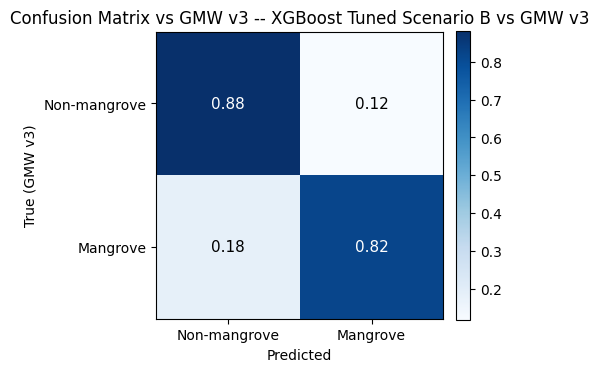

  Saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/figures/agreement_xgb_tuned_s2eq_sangatta_20250302_030003_92_4001.png


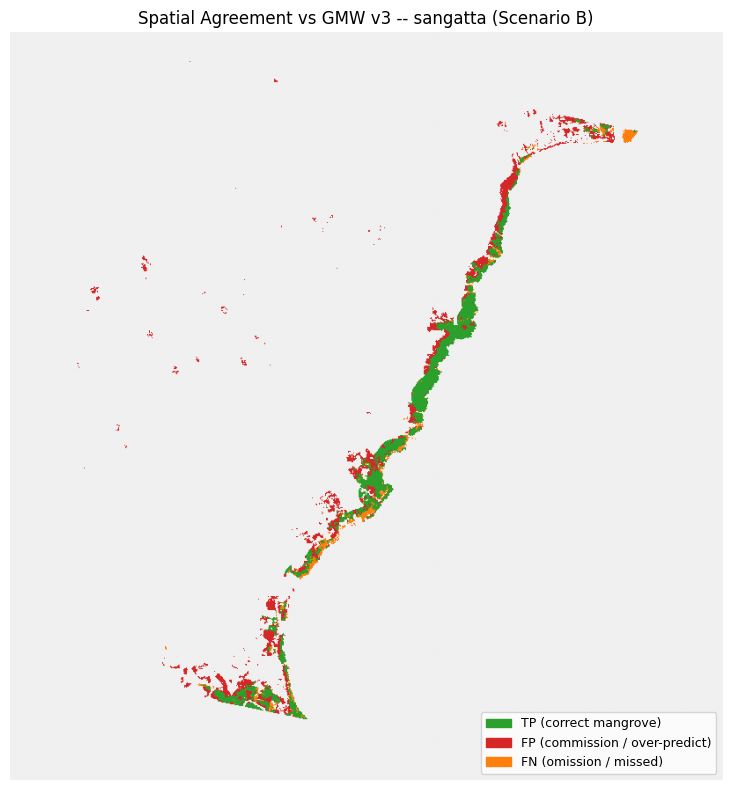

In [25]:
# ============================================================
# Confusion matrix and agreement map (Scenario B)
# ============================================================
plot_confusion_matrix(
    gmw_eval_b['confusion_matrix'],
    model_name='XGBoost Tuned Scenario B vs GMW v3',
    normalize=True,
    save_path=str(OUT_FIGURES / f'confusion_xgb_tuned_s2eq_{SITE}_{SCENE_ID}.png'),
)

plot_agreement_map(
    extent_b, gmw_raster,
    eval_mask=candidate_mask,
    site=f'{SITE} (Scenario B)',
    save_path=str(OUT_FIGURES / f'agreement_xgb_tuned_s2eq_{SITE}_{SCENE_ID}.png'),
)


## 7. Kappa A vs Kappa B Comparison -- XGBoost Tuned (Sangatta)

Compare Scenario A (6-feature: NDMI, MVI, MNDWI, SAVI, EMI, REIP) vs Scenario B (4-feature: NDMI, MVI, MNDWI, SAVI) at the training site, using **the same model (XGBoost Tuned) with the same hyperparameters** in both scenarios. Only the feature stack differs.

Scenario A metrics loaded from `model_comparison_sangatta_*.csv` (NB02 Section 8, XGBoost Tuned row), NOT from `gmw_eval_*.csv` which stores the RF Default baseline.

Transfer sites will be evaluated in `04b_transferability.ipynb`.

In [26]:
# ============================================================
# Load Scenario A XGBoost Tuned metrics from model_comparison CSV
# NB02 Section 8 writes this file with rows for RF Default, RF Tuned,
# and XGBoost Tuned. We select the XGBoost Tuned row.
# ============================================================
comp_a_path = OUT_RESULTS / f'model_comparison_{SITE}_{SCENE_ID}.csv'
if not comp_a_path.exists():
    print(f'Scenario A model comparison not found: {comp_a_path.name}')
    print('Run 02_classification.ipynb Section 8 first.')
else:
    df_comp_a = pd.read_csv(comp_a_path)
    print('Scenario A models available in model_comparison:')
    print(df_comp_a[['Model']].to_string(index=False))

    # Select XGBoost Tuned row
    row_xgb_a = df_comp_a[df_comp_a['Model'] == 'XGBoost Tuned'].copy()
    if row_xgb_a.empty:
        print('\nWARNING: XGBoost Tuned row not found. Available models above.')
    else:
        row_xgb_a['Scenario'] = 'A (6 features)'

        # Scenario B row (rename column to match Scenario A schema if needed)
        df_b = gmw_eval_b['metrics_table'].copy()
        df_b['Scenario'] = 'B (4 features)'

        # Normalize column names across scenarios
        # NB02 model_comparison uses: Model, Kappa, Precision, Recall, F1, IoU
        # evaluate_against_gmw uses:  Model, OA, Kappa, Precision, Recall, F1_mangrove, IoU
        if 'F1_mangrove' in df_b.columns and 'F1' not in df_b.columns:
            df_b = df_b.rename(columns={'F1_mangrove': 'F1'})

        df_compare = pd.concat([row_xgb_a, df_b], ignore_index=True)
        cols = ['Scenario', 'Model', 'Kappa', 'Precision', 'Recall', 'F1', 'IoU']
        df_compare = df_compare[[c for c in cols if c in df_compare.columns]]

        # Compute delta B - A
        if len(df_compare) == 2:
            print('\n  Sangatta -- Scenario A vs Scenario B (XGBoost Tuned, same hyperparameters):')
            print(df_compare.to_string(index=False))

            delta_row = {'Scenario': 'Delta (B - A)', 'Model': ''}
            for metric in ['Kappa', 'Precision', 'Recall', 'F1', 'IoU']:
                if metric in df_compare.columns:
                    a_val = df_compare.iloc[0][metric]
                    b_val = df_compare.iloc[1][metric]
                    try:
                        delta_row[metric] = round(float(b_val) - float(a_val), 4)
                    except (TypeError, ValueError):
                        delta_row[metric] = None
            df_final = pd.concat(
                [df_compare, pd.DataFrame([delta_row])], ignore_index=True
            )
            print('\n  With delta row:')
            print(df_final.to_string(index=False))

            df_final.to_csv(
                OUT_RESULTS / f'kappa_A_vs_B_{SITE}_{SCENE_ID}.csv', index=False
            )
            print(f'\n  Saved : kappa_A_vs_B_{SITE}_{SCENE_ID}.csv')


Scenario A models available in model_comparison:
        Model
   RF Default
     RF Tuned
XGBoost Tuned

  Sangatta -- Scenario A vs Scenario B (XGBoost Tuned, same hyperparameters):
      Scenario                      Model   Kappa  Precision  Recall       F1      IoU
A (6 features)              XGBoost Tuned 0.54881   0.624364 0.60616 0.615128 0.444176
B (4 features) XGBoost Tuned (Scenario B) 0.57720   0.540500 0.81810 0.650900 0.482500

  With delta row:
      Scenario                      Model   Kappa  Precision  Recall       F1      IoU
A (6 features)              XGBoost Tuned 0.54881   0.624364 0.60616 0.615128 0.444176
B (4 features) XGBoost Tuned (Scenario B) 0.57720   0.540500 0.81810 0.650900 0.482500
 Delta (B - A)                            0.02840  -0.083900 0.21190 0.035800 0.038300

  Saved : kappa_A_vs_B_sangatta_20250302_030003_92_4001.csv
